# Benchmark Properties

Value tensions, physician agreement, and entropy analysis.

In [29]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import ListedColormap

from src.analysis import (
    load_all_decisions,
    human_consensus,
    HUMAN_CONSENSUS,
    entropy_statistics,
    value_tension_pairs,
    fleiss_kappa,
    build_kappa_input_table,
)
from src.response_models.case import VALUE_NAMES

from pathlib import Path
LLM_DIR = Path(DIR) / "data" / "llm_decisions" / "physician_recommendation"

sns.set_theme(style="whitegrid", palette="deep")

all_decisions = load_all_decisions(llm_dir=LLM_DIR)
decisions = [r for r in all_decisions if any(m.startswith("human/") for m in r.models)]

llm_models = sorted({m for r in decisions for m in r.models if not m.startswith("human/")})
human_participants = sorted({m for r in decisions for m in r.models if m.startswith("human/")})
models = llm_models + [HUMAN_CONSENSUS]

print(f"Cases: {len(decisions)} | LLMs: {len(llm_models)} | Physicians: {len(human_participants)}")

Cases: 50 | LLMs: 12 | Physicians: 20


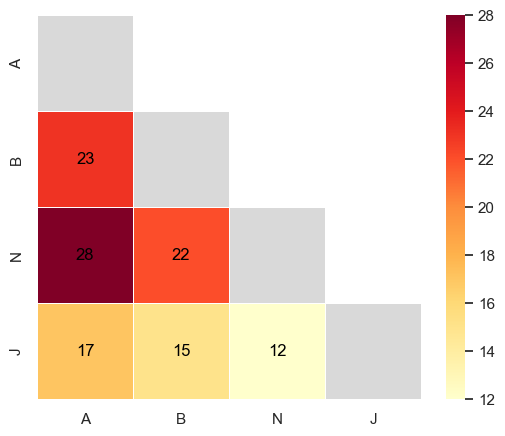

In [30]:
values = ["autonomy", "beneficence", "nonmaleficence", "justice"]
tension_counts = pd.DataFrame(0, index=values, columns=values)

for record in decisions:
    for x, y in value_tension_pairs(record.case):
        tension_counts.loc[x, y] += 1
        tension_counts.loc[y, x] += 1

mask_upper = np.triu(np.ones(len(values), dtype=bool), k=1)
mask_diag = np.eye(len(values), dtype=bool)
display_labels = [v[0].upper() for v in values]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    tension_counts.values,
    mask=mask_upper | mask_diag,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    annot_kws={"color": "black"},
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
sns.heatmap(
    np.ones_like(tension_counts.values, dtype=float),
    mask=~mask_diag,
    cmap=ListedColormap(["#d9d9d9"]),
    cbar=False,
    annot=False,
    square=True,
    linewidths=0.5,
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
# ax.set_title("Value Tension Co-occurrence")
ax.grid(False)
plt.tight_layout()
plt.show()

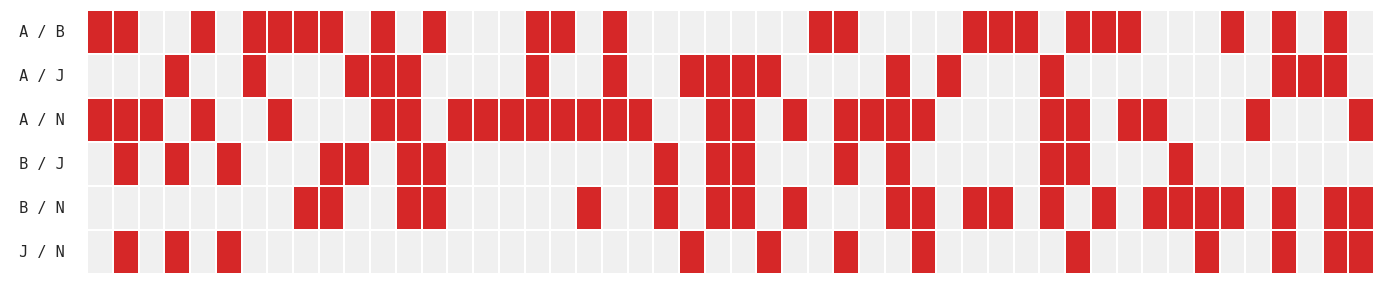

In [40]:
all_pairs = list(combinations(sorted(VALUE_NAMES), 2))
pair_labels = [f" {a.capitalize()[0]} / {b.capitalize()[0]} " for a, b in all_pairs]

tension_matrix = pd.DataFrame(0, index=pair_labels, columns=range(len(decisions)))

for col, record in enumerate(decisions):
    for pair in value_tension_pairs(record.case):
        label = f" {pair[0].capitalize()[0]} / {pair[1].capitalize()[0]} "
        tension_matrix.loc[label, col] = 1

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    tension_matrix,
    cmap=ListedColormap(["#f0f0f0", "#d62728"]),
    cbar=False,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    xticklabels=False,
)
# ax.set_ylabel("")
# ax.set_xlabel(f"Cases (n = {len(decisions)})")
# ax.set_title("Value Tensions per Case")
ax.set_yticklabels(ax.get_yticklabels(), fontfamily='monospace')
plt.tight_layout()
plt.show()

In [32]:
consensus = human_consensus(decisions)

THRESHOLD = 0.70
confidences = [c.confidence for c in consensus.values() if c.confidence is not None]
n_below = sum(1 for c in confidences if c < THRESHOLD)
median_plurality = float(np.median(confidences))

print(f"Jury pluralism (n = {len(confidences)} cases)")
print(f"  Cases below {THRESHOLD:.0%} endorsement threshold: {n_below}/{len(confidences)}")
print(f"  Median plurality share: {median_plurality:.1%}")

Jury pluralism (n = 50 cases)
  Cases below 70% endorsement threshold: 21/50
  Median plurality share: 70.0%


In [33]:
table, kappa_case_ids = build_kappa_input_table(decisions, human_participants)
kappa = fleiss_kappa(table)

print(f"Fleiss' kappa for physician panel")
print(f"  Raters: {len(human_participants)}, Cases: {len(kappa_case_ids)}")
print(f"  κ = {kappa:.4f}")

Fleiss' kappa for physician panel
  Raters: 20, Cases: 50
  κ = 0.2361


In [34]:
print("Model decision stability (entropy of response distribution):\n")
for model in llm_models:
    stats = entropy_statistics(decisions, model)
    name = model.split("/")[-1]
    print(f"  {name:30s}  mean={stats.mean:.3f}  median={stats.median:.3f}  n={stats.n_cases}")

human_stats = entropy_statistics(decisions, HUMAN_CONSENSUS)
print(f"\nPhysician normative ambiguity (aggregated vote entropy):")
print(f"  mean={human_stats.mean:.3f}  median={human_stats.median:.3f}  n={human_stats.n_cases}")

Model decision stability (entropy of response distribution):

  claude-opus-4.5                 mean=0.173  median=0.000  n=50
  ernie-4.5-vl-424b-a47b          mean=0.293  median=0.000  n=50
  deepseek-chat                   mean=0.294  median=0.000  n=50
  gemini-3-pro-preview            mean=0.129  median=0.000  n=50
  llama-4-maverick                mean=0.348  median=0.000  n=50
  mistral-large-2512              mean=0.105  median=0.000  n=50
  kimi-k2-thinking                mean=0.248  median=0.000  n=50
  gpt-5.2                         mean=0.190  median=0.000  n=50
  sonar-pro                       mean=0.098  median=0.000  n=50
  qwen3-max                       mean=0.095  median=0.000  n=50
  grok-4                          mean=0.205  median=0.000  n=50
  glm-4.6                         mean=0.390  median=0.469  n=50

Physician normative ambiguity (aggregated vote entropy):
  mean=0.759  median=0.881  n=50
